In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data_path = "../data/data.csv"
df = pd.read_csv(data_path)

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Check Data

In [15]:
print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)

# 1. Shape
print(f"\nDataset shape: {df.shape}")

# 2. Missing values
print("\n--- Missing Values ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})
print(missing_report[missing_report['missing_count'] > 0])
if missing_report['missing_count'].sum() == 0:
    print("No missing values found.")

# 3. Duplicate rows
print("\n--- Duplicate Rows ---")
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

# 4. Data types
print("\n--- Data Types ---")
print(df.dtypes)

# 5. Unique values for categorical columns
print("\n--- Unique Values (Categorical Columns) ---")
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    unique_vals = df[col].unique()
    print(f"{col}: {unique_vals}")

# 6. Basic stats for numerical columns
print("\n--- Numerical Column Statistics ---")
print(df.describe())

DATA QUALITY REPORT

Dataset shape: (7043, 21)

--- Missing Values ---
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []
No missing values found.

--- Duplicate Rows ---
Duplicate rows: 0

--- Data Types ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

--- Unique Values (Categorical Columns) ---
customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: ['Female' 'Male']
Partner:

In [16]:
# TotalCharges is object type rather than float
numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

In [17]:
# Check for invalid rows in any column
for col in numeric_cols:
    invalid_rows = df[pd.to_numeric(df[col], errors="coerce").isna()]
    print(col)
    display(invalid_rows.head())
    display(len(invalid_rows))

SeniorCitizen


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


0

tenure


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


0

MonthlyCharges


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


0

TotalCharges

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


11

In [18]:
invalid_tc = df[pd.to_numeric(df['TotalCharges'], errors="coerce").isna()]

Those with invalid rows for `TotalCharges` have tenure of 0 --> New customers. Likely not yet calculated

In [19]:
invalid_tc

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


# Prepare Data

In [20]:
# Fill invalid rows with median
# TODO: Try dropping them and rerun the model
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['TotalCharges'] =  df['TotalCharges'].astype(float)

In [21]:
# Drop non-useful columns
df.drop(columns=['customerID'], inplace=True)

In [22]:
# Convert binary columns
binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [23]:
# one-hot encoding for multiple categoroes
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

In [24]:
# df.dtypes

# Feature Engineering

In [25]:
# Bundle streaming services into 1
df["has_streaming"] = (
    (df['StreamingTV_Yes'] == 1) | 
    (df['StreamingMovies_Yes'] == 1)
).astype(int)

In [26]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,has_streaming
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,0
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,0
4,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.50,0,False,True,False,False,False,True,False,False,False,True,False,True,False,True,False,True,True,False,False,False,True,1
7039,0,0,1,1,72,1,1,103.20,7362.90,0,False,True,True,False,False,False,False,True,False,True,False,False,False,True,False,True,True,False,True,False,False,1
7040,0,0,1,1,11,0,1,29.60,346.45,0,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,0
7041,1,1,1,0,4,1,1,74.40,306.60,1,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,0


# Run Model

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [28]:
X = df.drop(columns="Churn")
y = df["Churn"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  #train 80%, test 20%
    random_state=42,
    stratify=y  # same churn ratio between train and test split
)

In [30]:
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Churn rate in train: {y_train.mean():.2%}")
print(f"Churn rate in test: {y_test.mean():.2%}")

Training set: (5634, 31)
Test set: (1409, 31)
Churn rate in train: 26.54%
Churn rate in test: 26.54%


In [31]:
# scale features
scaler = StandardScaler()

# fit_transform on training data, but only transform test data
# this prevents data leakage such that model remains unbiased
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [32]:
# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
# Ramdom Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
# XGboost
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


# Evaluate model

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [23]:
def evaluate_model(model, X_test, y_test, model_name):
    # model's prediction - churn or no churn
    y_pred = model.predict(X_test)
    # probability of churn or no churn
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    # % of correct predictions
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    # out of those who were predicted to churn, how many of them really churned
    # TP / (TP + FP)
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    # out of those who churned, how many were predicted to churn?
    # TP / (TP + FN)
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    # balances precision & recall
    print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
    # plots TP rate againt FP rate. Higher is better
    print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}")
    
    # Confusion matrix
    # TN, FP
    # FN, TP
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=axes[0]
    )
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    
    RocCurveDisplay.from_estimator(
        model, X_test, y_test, ax=axes[1]
    )
    axes[1].set_title(f'{model_name} — ROC Curve')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob)
    }


  Logistic Regression
Accuracy:  0.8006
Precision: 0.6458
Recall:    0.5508
F1 Score:  0.5945
AUC-ROC:   0.8417


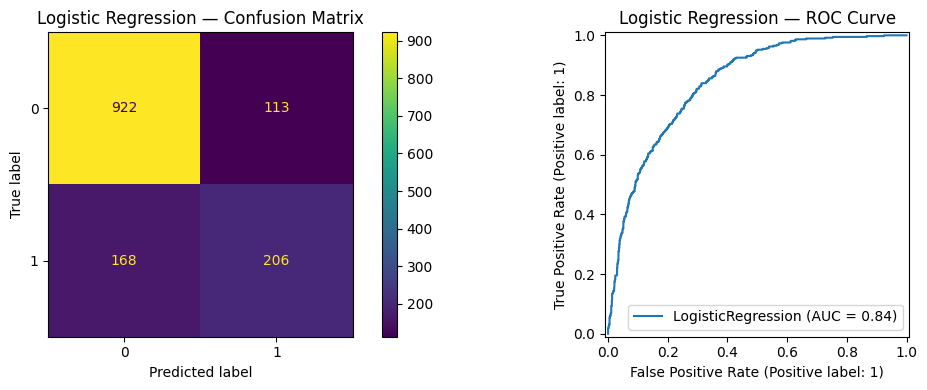


  Random Forest
Accuracy:  0.7885
Precision: 0.6267
Recall:    0.5027
F1 Score:  0.5579
AUC-ROC:   0.8235


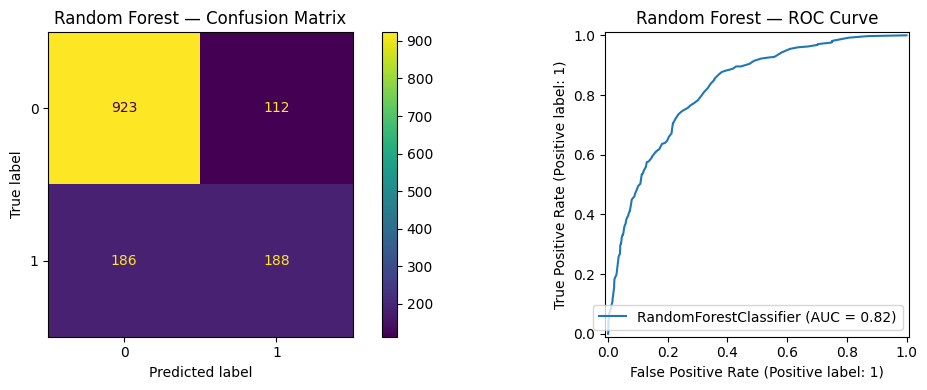


  XGBoost
Accuracy:  0.7814
Precision: 0.6038
Recall:    0.5134
F1 Score:  0.5549
AUC-ROC:   0.8233


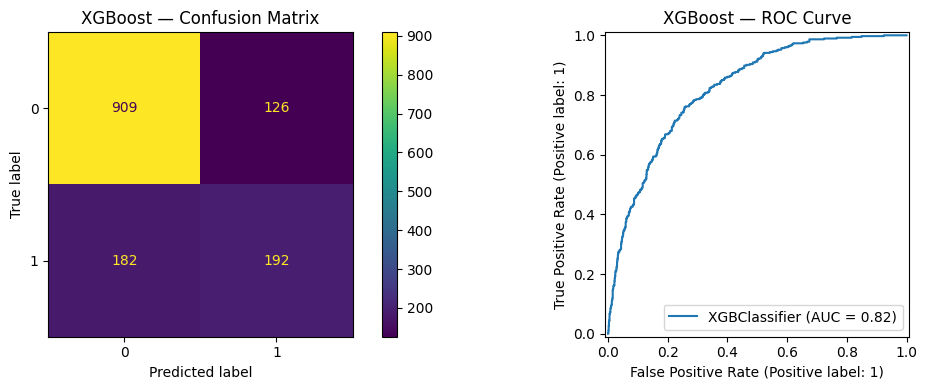

In [37]:
results = []
results.append(evaluate_model(lr, X_test, y_test, "Logistic Regression"))
results.append(evaluate_model(rf, X_test, y_test, "Random Forest"))
results.append(evaluate_model(xgb, X_test, y_test, "XGBoost"))

In [38]:
results_df = pd.DataFrame(results).set_index('model')

In [39]:
results_df

,accuracy,precision,recall,f1,auc
model,,,,,
Logistic Regression,0.800568,0.645768,0.550802,0.594517,0.841703
Random Forest,0.788502,0.626667,0.502674,0.557864,0.823469
XGBoost,0.781405,0.603774,0.513369,0.554913,0.823312


# Feature Importance

In [40]:
from sklearn.metrics import precision_recall_curve

In [41]:
importance_lr = pd.DataFrame({
    'feature': X_train.columns,
    'Logistic Regression': np.abs(lr.coef_[0])
}).sort_values('Logistic Regression', ascending=False).head(15)

In [42]:
importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'Random Forest': rf.feature_importances_
}).sort_values('Random Forest', ascending=False).head(15)

In [43]:
importance_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'XGboost': xgb.feature_importances_
}).sort_values('XGboost', ascending=False).head(15)

In [44]:
importance_df = importance_lr.merge(importance_rf, on="feature", how="outer").merge(importance_xgb, on="feature", how="outer")

In [45]:
importance_df.head()

,feature,Logistic Regression,Random Forest,XGboost
0,Contract_One year,0.694148,0.021407,0.090103
1,Contract_Two year,1.351964,0.034337,0.140556
2,Dependents,NaN,NaN,0.010076
3,InternetService_Fiber optic,1.159579,0.042507,0.447759
4,InternetService_No,NaN,NaN,0.094925


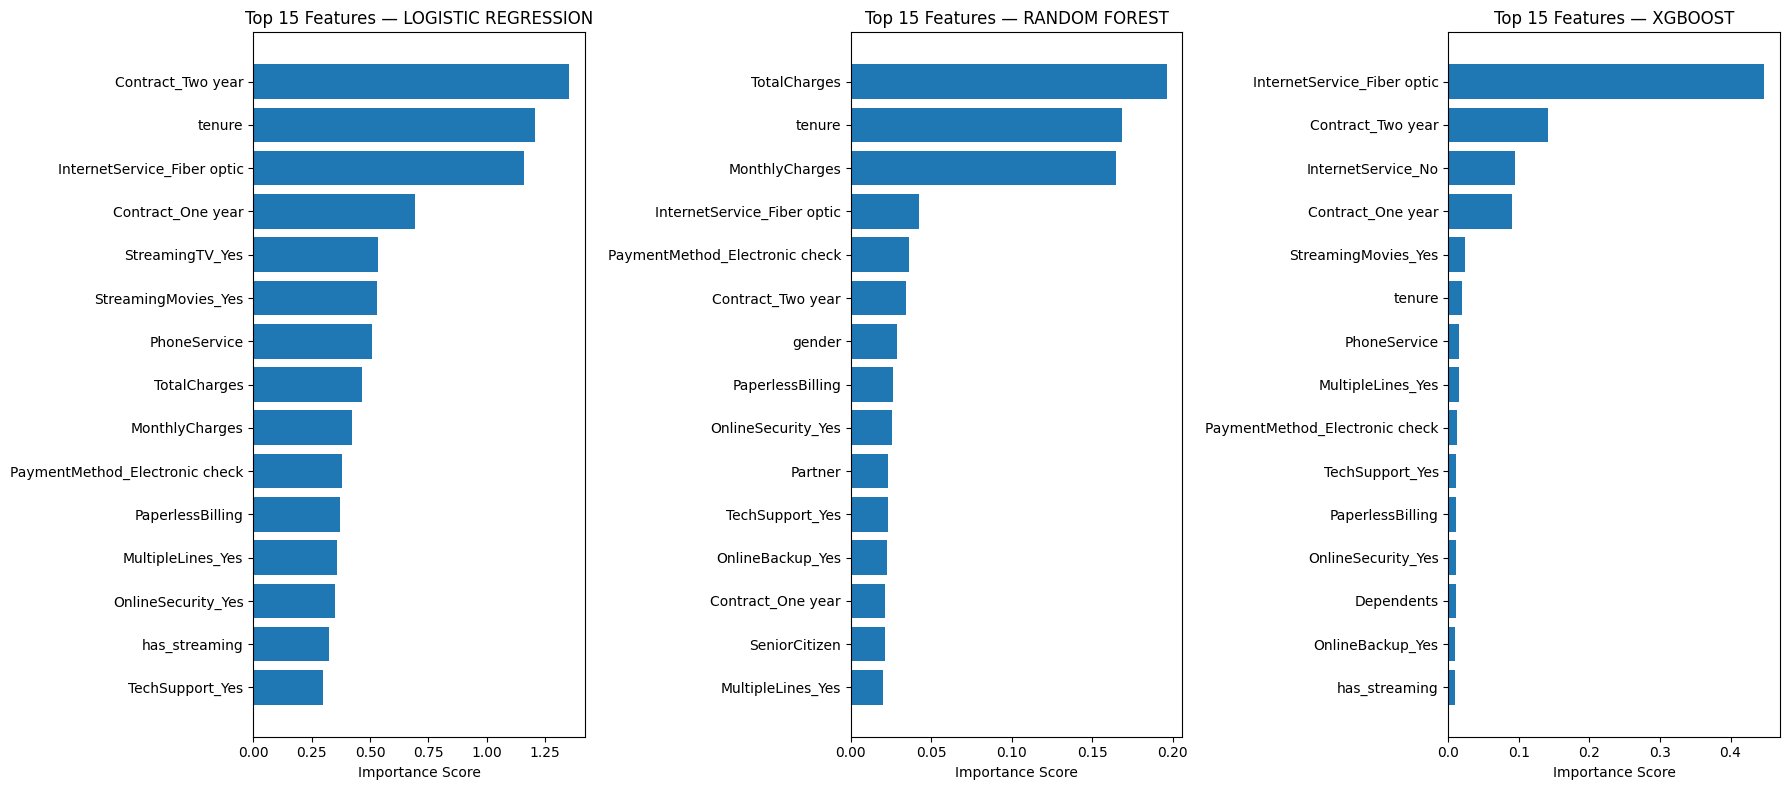

In [46]:
models = [col for col in importance_df.columns if col != "feature"]

fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=False)

for ax, model in zip(axes, models):
    
    # Get top 15 features for each model
    top_feats = (
        importance_df[['feature', model]]
        .sort_values(by=model, ascending=False)
        .head(15)
    )

    ax.barh(top_feats['feature'], top_feats[model])
    ax.set_title(f'Top 15 Features — {model.upper()}')
    ax.set_xlabel('Importance Score')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

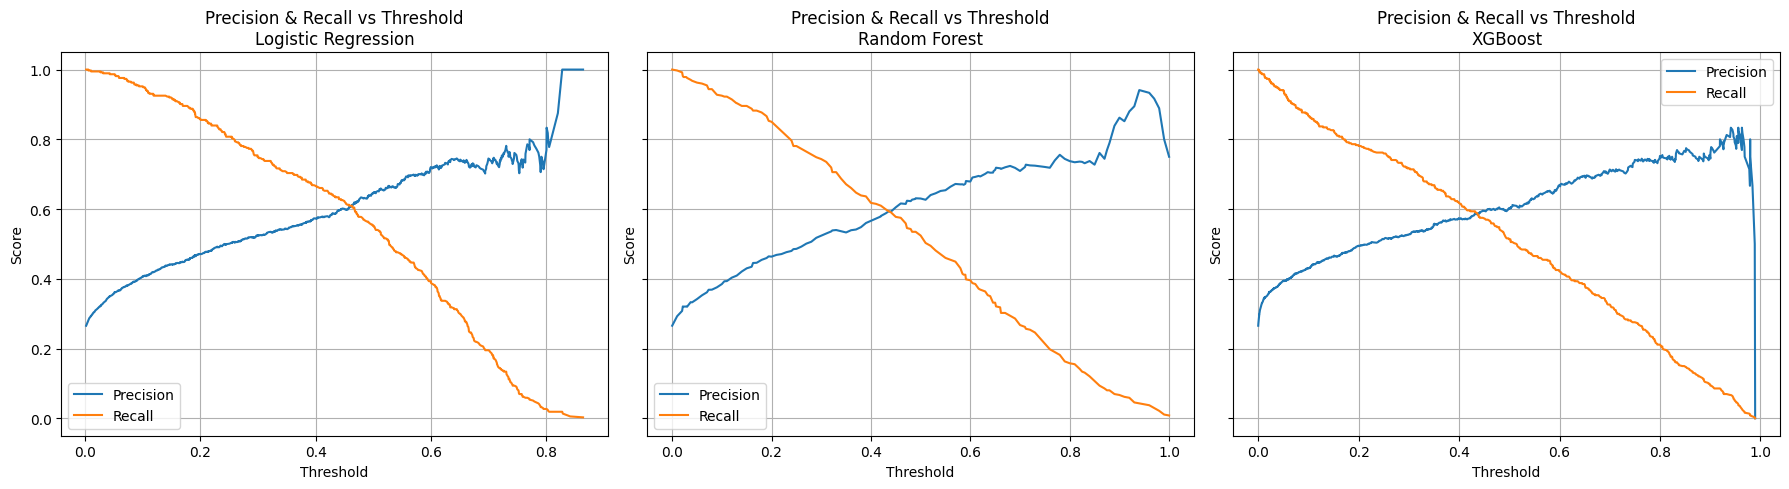

In [47]:
# predicted probabilities
y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# store models
models = {
    'Logistic Regression': y_prob_lr,
    'Random Forest': y_prob_rf,
    'XGBoost': y_prob_xgb,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (model_name, y_prob) in zip(axes, models.items()):

    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

    ax.plot(thresholds, precisions[:-1], label='Precision')
    ax.plot(thresholds, recalls[:-1], label='Recall')

    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'Precision & Recall vs Threshold\n{model_name}')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# Save model

Overall, Logistic Regression is doing better for every metric, compared to Random Forest and XGboost.

In [22]:
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

## Prepare data

In [41]:
data_path = "../data/data.csv"
df = pd.read_csv(data_path)

In [42]:
# Fill invalid rows with median
# TODO: Try dropping them and rerun the model
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['TotalCharges'] =  df['TotalCharges'].astype(float)

In [43]:
# Drop non-useful columns
df.drop(columns=['customerID'], inplace=True)

In [44]:
# Convert binary columns
# binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
binary_cols = ['Churn',]
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [45]:
# Bundle streaming services into 1
df["has_streaming"] = (
    (df['StreamingTV'] == "Yes") | 
    (df['StreamingMovies'] == "Yes")
).astype(int)

In [46]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,has_streaming
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0


In [47]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

## Preprocessor and pipeline

In [53]:
categorical_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "has_streaming",
]

numerical_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen"
]

In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)


In [55]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

## Generate model

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]
print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.8415743108837738


## Save

In [25]:
# joblib.dump(lr, '../models/churn_model.pkl')
# joblib.dump(scaler, '../models/scaler.pkl')

# print("Model and scaler saved.")

In [60]:
# Save feature names
feature_names = list(X_train.columns)
joblib.dump(feature_names, '../models/feature_names.pkl')

['../models/feature_names.pkl']

In [29]:
# # Save sample
# sample_customers = X_test.head(5).copy()
# sample_customers['actual_churn'] = y_test.head(5).values
# sample_customers.to_csv('../data/sample_data.csv', index=False)

In [59]:
joblib.dump(pipeline, "../models/churn_pipeline.pkl")

print("Pipeline saved.")

Pipeline saved.
